### Heart Attack Prediction - Coursework 1

#### Problem Definition

Heart attacks are a serious condition and a life-threatening emergency. Artificial Intelligence can help predict heart attacks and save lives. 
We are looking for an AI-based model to predict the heart attack given some health indicators such as BMI, age, being a smoker, with high accuracy. <br>
Please write a report in 1500 words explaining in detail different stages of achieving the goal of this project. The report should include the following steps in detail. The dataset has been provided for you on Moodle. <br>
1.1 Prepare the dataset for training (Check for missing values, splitting the dataset in training and testing datasets…). <br>
1.2 Choose and tailor 4 Models you have learnt during lectures including an ANN-based model and train and build the models. <br>
1.3 Evaluate your model using metrics you have learnt during the lectures. <br>
1.4 Compare the models and report the most accurate model for this purpose. <br>
1.5 Please provide 2 ways (with evidence) to further improve the accuracy of your best model.

#### Project Goal

- To create a model that can predict whether someone will get a heart attack or not

Project sections:
1. Data ingestion, Data preprocessing, Data segragation
2. Model selection, Model training
3. Model evaluation (use all metrics) - recall is the most important
4. Compare selected models and report the most accurate model
5. Provide 2 ways (with evidence) to further improve the accuracy of the model selected in (4)

#### Importing Required Python Libraries

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, roc_auc_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


#### Section 1

##### 1.1 Data Ingestion

In [2]:
heart_data = pd.read_csv("heart_attack.csv")
heart_data.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4


##### 1.2 Data Insights/Analysis

In [3]:
# Every feature is of integer type, so encoding is not necessary for this dataset
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129998 entries, 0 to 129997
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  129998 non-null  int64  
 1   HighBP                129998 non-null  int64  
 2   HighChol              129998 non-null  int64  
 3   CholCheck             129998 non-null  int64  
 4   BMI                   129988 non-null  float64
 5   Smoker                129998 non-null  int64  
 6   Stroke                129998 non-null  int64  
 7   Diabetes              129998 non-null  int64  
 8   PhysActivity          129998 non-null  int64  
 9   HvyAlcoholConsump     129998 non-null  int64  
 10  MentHlth              129998 non-null  int64  
 11  PhysHlth              129998 non-null  int64  
 12  Sex                   129998 non-null  int64  
 13  Age                   129998 non-null  int64  
 14  Education             129998 non-null  int64  
 15  

In [4]:
# statistical analysis of the data
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,129998.0,0.093509,0.291146,0.0,0.0,0.0,0.0,1.0
HighBP,129998.0,0.429614,0.495023,0.0,0.0,0.0,1.0,1.0
HighChol,129998.0,0.426322,0.494544,0.0,0.0,0.0,1.0,1.0
CholCheck,129998.0,0.963315,0.187988,0.0,1.0,1.0,1.0,1.0
BMI,129988.0,28.435586,6.999582,12.0,24.0,27.0,31.0,98.0
Smoker,129998.0,0.448030,0.497294,0.0,0.0,0.0,1.0,1.0
Stroke,129998.0,0.041354,0.199110,0.0,0.0,0.0,0.0,1.0
Diabetes,129998.0,0.296689,0.697608,0.0,0.0,0.0,0.0,2.0
PhysActivity,129998.0,0.760758,0.426622,0.0,1.0,1.0,1.0,1.0
HvyAlcoholConsump,129998.0,0.057562,0.232915,0.0,0.0,0.0,0.0,1.0


Points I noted from the stats above;
1. Only 9.35% of people had a heart attack according to the dataset, hence there's a bias towards people not getting heart attacks
2. 96% of people went for cholesterol check
3. The highest BMI value is 98, these are likely outliers and might be dropped
4. 76% of people are physically active
5. Only 5.7% of people are heavy alcohol consumers
6. The average age group of the dataset is between 60-64 (age group 8)
7. BMI, Diabetes, MentHlth, PhysHlth, Age, Education, and Income are not binary values

In [5]:
# checking for null values
heart_data.isnull().sum()

HeartDiseaseorAttack     0
HighBP                   0
HighChol                 0
CholCheck                0
BMI                     10
Smoker                   0
Stroke                   0
Diabetes                 0
PhysActivity             0
HvyAlcoholConsump        0
MentHlth                 0
PhysHlth                 0
Sex                      0
Age                      0
Education                0
Income                   0
dtype: int64

Points I noted from the null values output;
1. BMI has 10 null values

##### Visualizing Outcome Data Distribution
- As we identified from the dataset stats, only 9.35% of people had a heart attack according to the dataset, hence there's a bias towards people not getting heart attacks. Below is a visual representation of the same.

/var/folders/cj/x4b957m11wb_2wmjnhdlq2400000gn/T/ipykernel_94796/180961742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=Y, data=heart_data, palette='Set2')


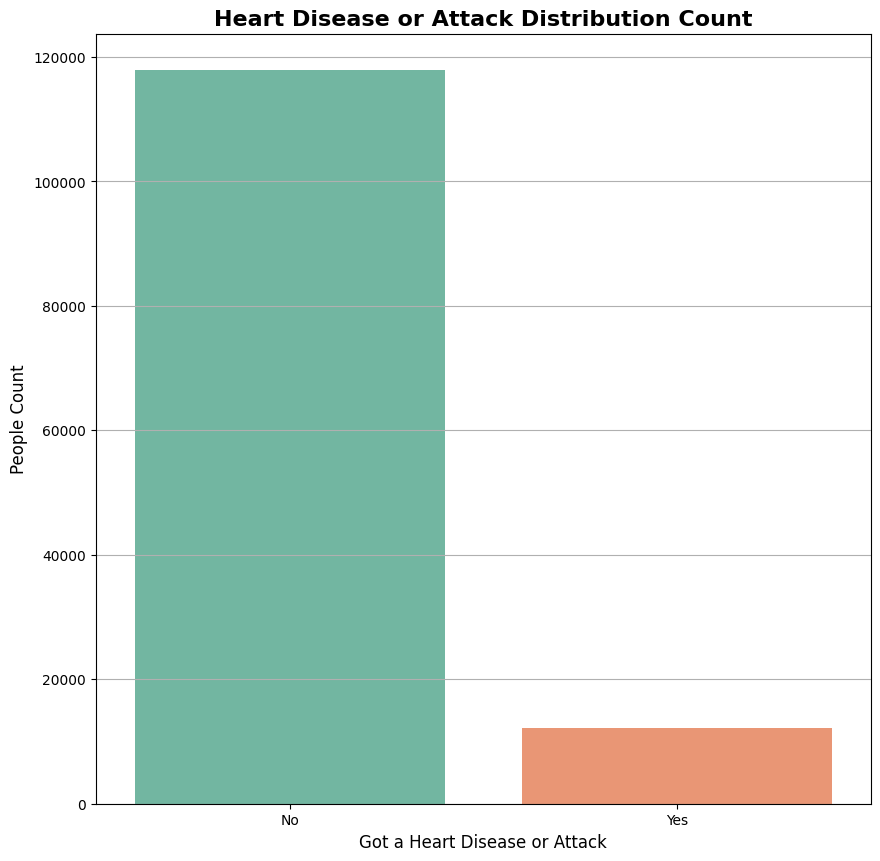

In [6]:
Y = heart_data['HeartDiseaseorAttack']
plt.figure(figsize=(10,10))
sb.countplot(x=Y, data=heart_data, palette='Set2')
plt.title("Heart Disease or Attack Distribution Count", fontweight="bold", fontsize=16)
plt.xlabel("Got a Heart Disease or Attack", fontsize=12)
plt.ylabel("People Count", fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(visible=True, axis='y')
plt.show()



##### Visualizing Non-binary Numerical Data Distribution

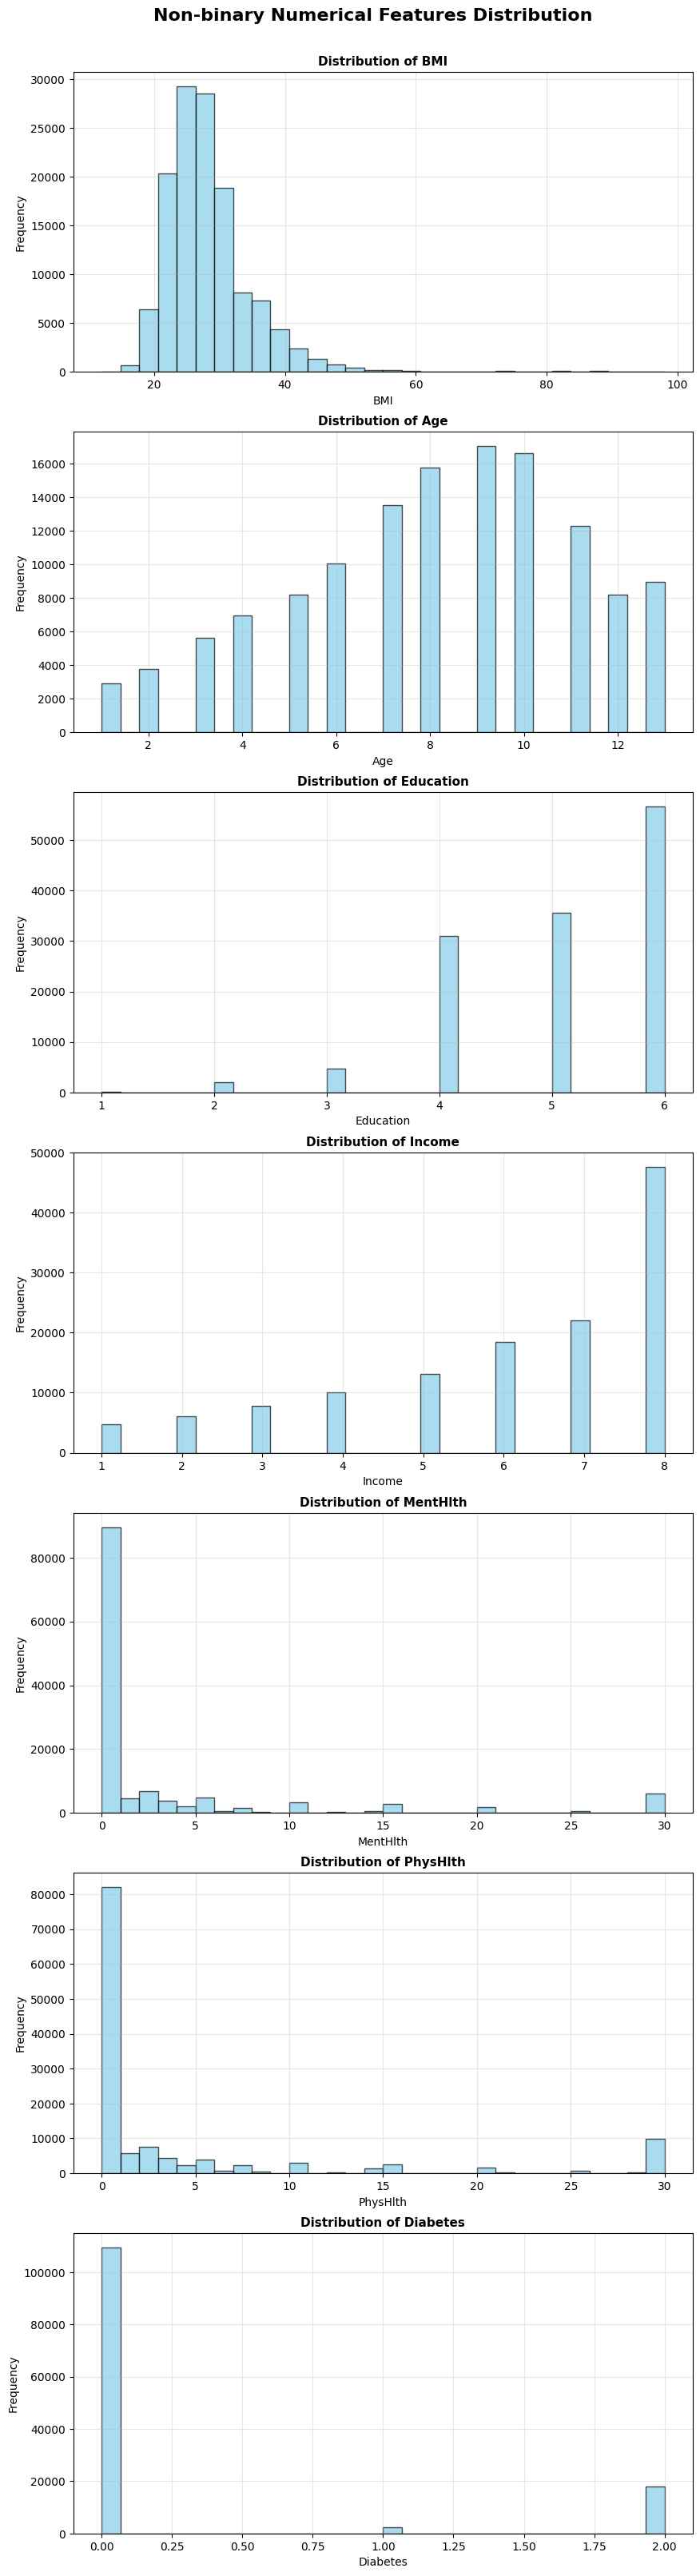

In [7]:
non_binary_numerical_columns = ['BMI','Age', 'Education', 'Income', 'MentHlth', 'PhysHlth', 'Diabetes' ]
n_columns = 1
n_rows = 7
figure, axes = plt.subplots(n_rows, n_columns, figsize=(10, 40))
axes = axes.flatten()

for x_axis, y_axis in enumerate(non_binary_numerical_columns):
    axes[x_axis].hist(heart_data[y_axis], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[x_axis].set_title(f'Distribution of {y_axis}', fontsize=11, fontweight='bold')
    axes[x_axis].set_xlabel(y_axis, fontsize=10)
    axes[x_axis].set_ylabel('Frequency', fontsize=10)
    axes[x_axis].grid(True, alpha=0.3)

plt.suptitle("Non-binary Numerical Features Distribution", fontsize=16, fontweight="bold", y=0.9)
plt.show()


##### 1.2 Data Pre-processing

In [8]:
# checking for null values
heart_data.isnull().sum()

HeartDiseaseorAttack     0
HighBP                   0
HighChol                 0
CholCheck                0
BMI                     10
Smoker                   0
Stroke                   0
Diabetes                 0
PhysActivity             0
HvyAlcoholConsump        0
MentHlth                 0
PhysHlth                 0
Sex                      0
Age                      0
Education                0
Income                   0
dtype: int64

due to availability of sufficient data and low null value row count, I decided to drop rows with null values

In [9]:
heart_data_dropped_nan = heart_data.dropna()
heart_data_dropped_nan.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
HvyAlcoholConsump       0
MentHlth                0
PhysHlth                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
# checking for 0 value in ordinal features/columns
cols_no_zero_allowed = ["Age", "Education", "Income"]

for col in cols_no_zero_allowed:
    zero_count = (heart_data_dropped_nan[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

Age: 0 zero values
Education: 0 zero values
Income: 0 zero values


Ordinal categorical variables (Age, Education, Income) were inspected for invalid zero values. No inconsistencies were detected. Other variables legitimately allow zero values (e.g., 0 unhealthy days, 0 smoking status), therefore no zero-value imputation was required.

Next, I evaluated the correlation analysis of features in the dataset to check for feature redundancy.
A correlation heatmap was generated to examine relationships between predictor variables and detect potential multicollinearity. Features with absolute correlation values greater than 0.8 were considered candidates for removal. No highly correlated predictors were identified, therefore all variables were retained for model training.

In [11]:

heart_data_correlation_matrix = heart_data_dropped_nan.drop('HeartDiseaseorAttack', axis=1).corr()
heart_data_correlation_matrix

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
HighBP,1.000000,0.297264,0.098667,0.203393,0.097617,0.128930,0.273298,-0.127643,-0.008999,0.055358,0.158593,0.047396,0.341526,-0.142332,-0.172278
HighChol,0.297264,1.000000,0.085881,0.098517,0.089150,0.090431,0.210785,-0.078146,-0.014512,0.060518,0.120949,0.029343,0.272947,-0.069054,-0.085526
CholCheck,0.098667,0.085881,1.000000,0.033625,-0.010924,0.024493,0.067325,0.005694,-0.022406,-0.009104,0.030472,-0.023645,0.089687,0.003558,0.017792
BMI,0.203393,0.098517,0.033625,1.000000,0.008881,0.018458,0.210638,-0.144283,-0.048076,0.083905,0.114756,0.040434,-0.042251,-0.099991,-0.100561
Smoker,0.097617,0.089150,-0.010924,0.008881,1.000000,0.061210,0.061023,-0.089105,0.100043,0.091191,0.117075,0.087966,0.125028,-0.166912,-0.131211
Stroke,0.128930,0.090431,0.024493,0.018458,0.061210,1.000000,0.106085,-0.070931,-0.017654,0.077616,0.153491,0.001878,0.126518,-0.078568,-0.132727
Diabetes,0.273298,0.210785,0.067325,0.210638,0.061023,0.106085,1.000000,-0.124229,-0.058051,0.077076,0.176675,0.026898,0.181623,-0.131728,-0.171710
PhysActivity,-0.127643,-0.078146,0.005694,-0.144283,-0.089105,-0.070931,-0.124229,1.000000,0.014490,-0.128765,-0.222807,0.031314,-0.093593,0.203518,0.197587
HvyAlcoholConsump,-0.008999,-0.014512,-0.022406,-0.048076,0.100043,-0.017654,-0.058051,0.014490,1.000000,0.022450,-0.027766,0.001878,-0.033917,0.023600,0.052878
MentHlth,0.055358,0.060518,-0.009104,0.083905,0.091191,0.077616,0.077076,-0.128765,0.022450,1.000000,0.357984,-0.081337,-0.093022,-0.107210,-0.215318


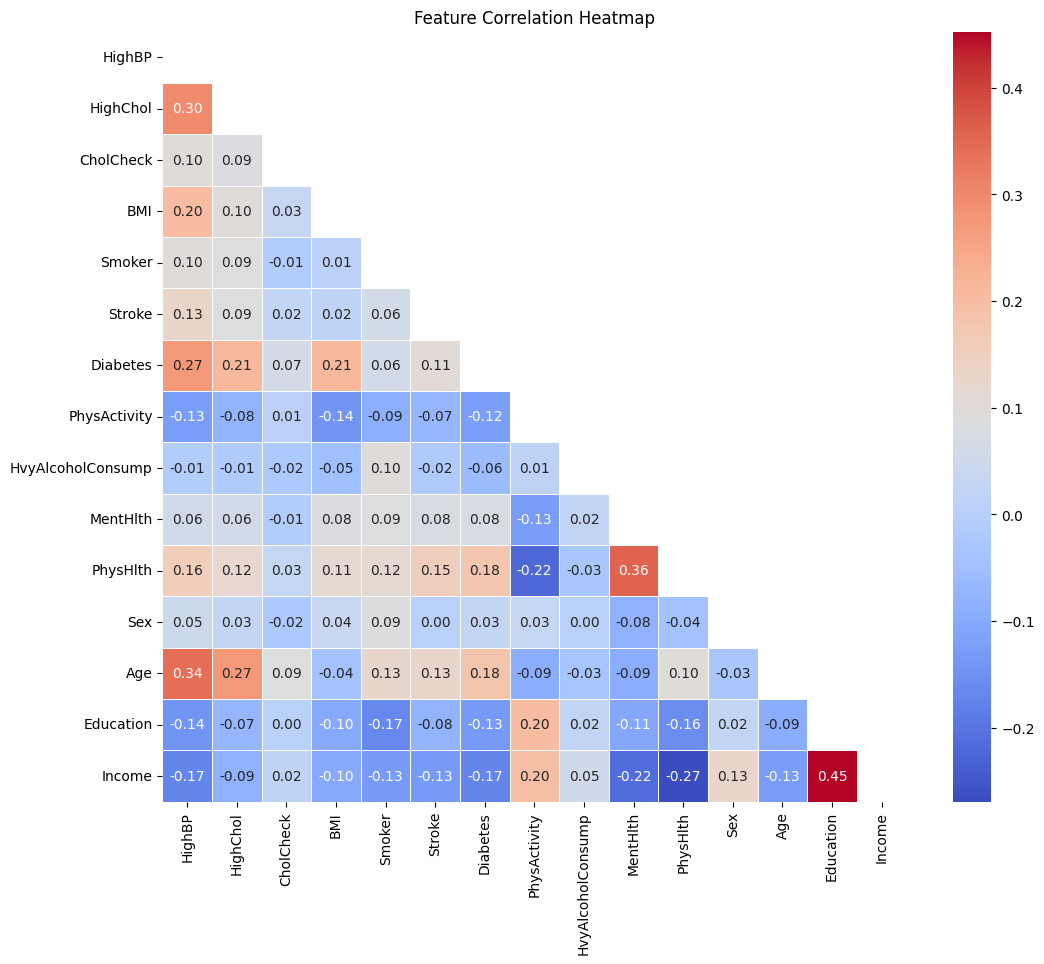

In [12]:
plt.figure(figsize=(12,10))

mask = np.triu(np.ones_like(heart_data_correlation_matrix, dtype=bool))

sb.heatmap(
    heart_data_correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

##### 1.3 Data Segregation

In [13]:
# separate features from target/outcome
X = heart_data_dropped_nan.drop('HeartDiseaseorAttack', axis=1)
print("======================================================================")
print(X)
print("======================================================================")
# assign target to y
y = heart_data_dropped_nan['HeartDiseaseorAttack']
print("======================================================================")
print(y)
print("======================================================================")

        HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  Diabetes  \
0            1         1          1  40.0       1       0         0   
1            0         0          0  25.0       1       0         0   
2            1         1          1  28.0       0       0         0   
3            1         0          1  27.0       0       0         0   
4            1         1          1  24.0       0       0         0   
...        ...       ...        ...   ...     ...     ...       ...   
129993       1         1          1  25.0       1       0         0   
129994       0         0          1  27.0       0       0         0   
129995       0         0          1  29.0       0       0         0   
129996       0         0          0  21.0       0       0         0   
129997       0         0          1  21.0       1       0         0   

        PhysActivity  HvyAlcoholConsump  MentHlth  PhysHlth  Sex  Age  \
0                  0                  0        18        15    0    9   
1

In [14]:
# splitting the dataset into training and testing data. 
# since data is sufficient, I did a 70-30 split
X_train, X_test, Y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=0)

print("X_train Shape:", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("Y_train Shape: ", Y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape: (90991, 15)
X_test Shape:  (38997, 15)
Y_train Shape:  (90991,)
y_test Shape:  (38997,)


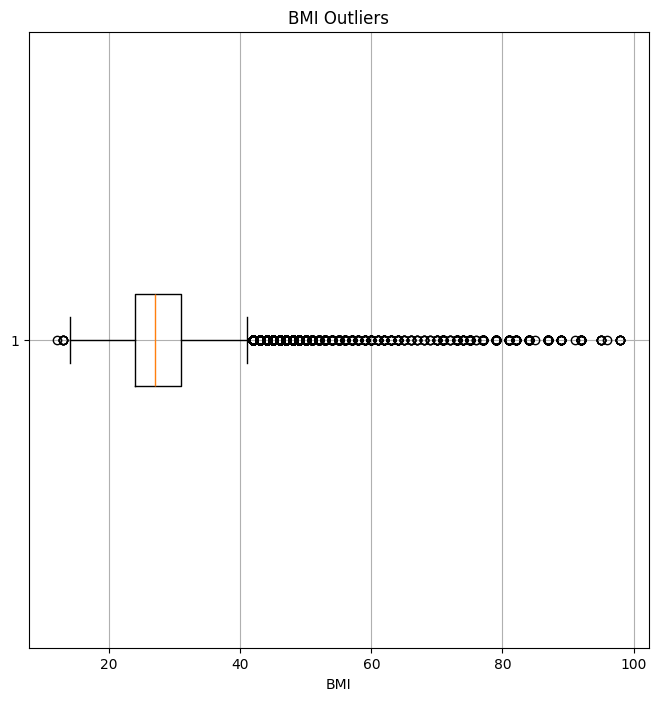

In [15]:
# outlier detection - primarily relevant for continuouos variables (BMI in this case)
# the purpose for this is to identify extreme observations that could distort models
# outliers can distort scaling and model fitting
plt.figure(figsize=(8,8))
plt.boxplot(X_train["BMI"], vert=False)
plt.title("BMI Outliers")
plt.xlabel("BMI")
plt.grid(True)
plt.show()

In [16]:
# using interquartile range to filter outliers in the visual above
Q1 = X_train["BMI"].quantile(0.25)
Q3 = X_train["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# I clipped the rows to avoid data loss
X_train["BMI"] = X_train["BMI"].clip(lower_bound, upper_bound)
X_test["BMI"] = X_test["BMI"].clip(lower_bound, upper_bound)

Outlier analysis was conducted using boxplots and the interquartile range (IQR) method. BMI was identified as the only continuous feature with potential extreme values, with the maximum value reaching 98. Values outside the IQR bounds were capped to reduce the influence of extreme observations while preserving the dataset size.

##### Feature Scaling
Importance: Many machine learning algorithms are sensitive to the scale of the input features e.g. Algorithms that rely on distance metrics (like KNN and SVM) or gradient-based optimization (like Logistic Regression and Gradient Boosting) can be affected by features with different scales.
<br>
<br>
Impact of Unscaled Features: If features like Glucose (values in the range of 0-200) and BMI (values in the range of 0-70) are not scaled, the model may give more importance to features with larger ranges, leading to biased results.
<br>
<br>
Standardization or Normalization: Scaling ensures that all features contribute equally to the model. Standardization (z-score normalization) or Min-Max scaling are common techniques.
<br>
<br>
Tree-Based Models: Models like Decision Trees and Random Forests are not sensitive to feature scaling, so scaling is not strictly necessary for them.

In the heart_disease dataset, BMI can dominate the model because it has larger numeric values, not because it is more important.
Scaling ensures all the features contribute proportionally during model training

In [17]:
numeric_columns = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income",
    "Diabetes"
]

binary_columns = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "PhysActivity",
    "HvyAlcoholConsump",
    "Sex"
]

preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_columns),
    ("bin", "passthrough", binary_columns) 
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

Numerical features were standardised using the StandardScaler to ensure that variables with larger numeric ranges did not dominate model learning. The scaler was fitted using the training data and subsequently applied to the test set to prevent data leakage. Binary features were left unchanged as they already exist on a comparable scale.

##### Data Augmentation
I'm using data augmentation to balance the dataset which eventually reduces bias <br>
Augmentation is done on the training dataset, after pre-processing

In [18]:
count = Counter(y)
print(count)
oversample = SMOTE()
X_train_sm, Y_train_sm = oversample.fit_resample(X_train_scaled, Y_train)
print("balanced after augmentation")
print(Counter(Y_train_sm))

Counter({0: 117833, 1: 12155})
balanced after augmentation


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Counter({0: 82486, 1: 82486})


##### Model Selection
Five classification models were implemented to provide methodological diversity: Logistic Regression as a linear baseline model, K-Nearest Neighbours as a distance-based classifier, Decision Tree as an interpretable nonlinear model, Random Forest as an ensemble learning method, and an Artificial Neural Network to capture complex patterns in the data. 
Since KNN and ANN rely on feature distance calculations, numerical variables were standardised prior to model training to ensure that features with larger numeric ranges did not dominate the distance metric.
Logistic regression also performs better with scaled data

1. Logistic Regression
2. K-Nearest Neighbours
3. Decision Tree
4. Random Forest
5. ANN

1. Logistic Regression

In [39]:
# model training - LR
lr = LogisticRegression()
lr.fit(X_train_scaled, Y_train)


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn

LogisticRegression()

In [33]:
ylrpredicted = lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, ylrpredicted)
print(cm_lr)

[[35042   305]
 [ 3289   361]]


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<Axes: >

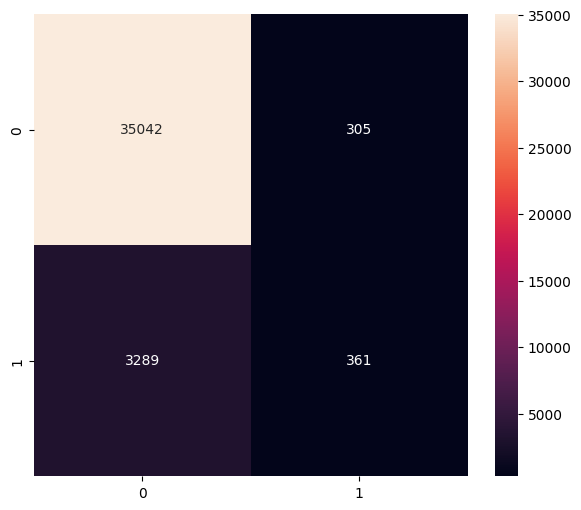

In [34]:
plt.figure(figsize=(7,6))
sb.heatmap(cm_lr, annot=True, fmt='d')

2. K-Nearest Neighbours

In [35]:
KNN = KNeighborsClassifier(n_neighbors=2)
KNN.fit(X_train_sm, Y_train_sm)

KNeighborsClassifier(n_neighbors=2)

In [36]:
yknnpredicted = KNN.predict(X_test_scaled)
knn_cm = confusion_matrix(y_test, yknnpredicted)
print(knn_cm)

[[32069  3278]
 [ 2643  1007]]


<Axes: >

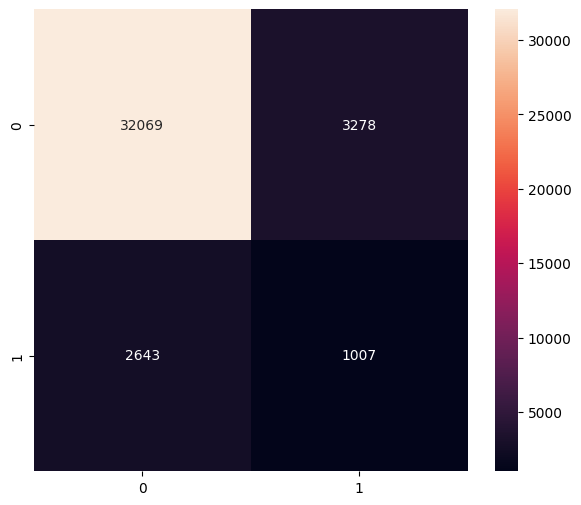

In [37]:
plt.figure(figsize=(7,6))
sb.heatmap(knn_cm, annot=True, fmt='d')

3. Decision Tree

In [40]:
# question - how does max_depth and entropy affect how a model trains
dt = DecisionTreeClassifier()
dt.fit(X_train_sm, Y_train_sm)

DecisionTreeClassifier()

In [41]:
ydtpredicted = dt.predict(X_test_scaled)
dt_cm = confusion_matrix(y_test, ydtpredicted)
print(dt_cm)

[[32153  3194]
 [ 2775   875]]


<Axes: >

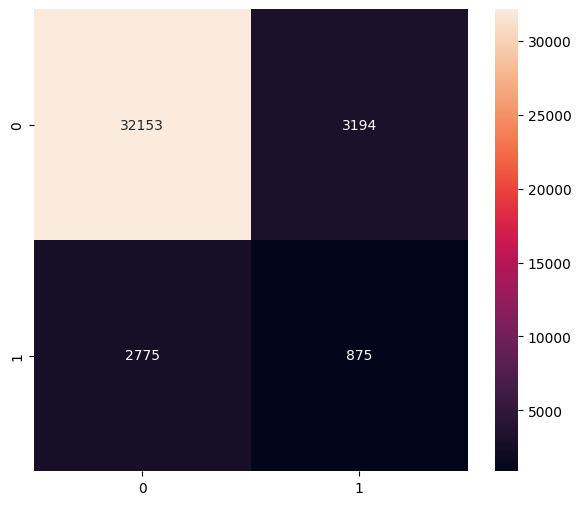

In [44]:
plt.figure(figsize=(7,6))
sb.heatmap(dt_cm, annot=True, fmt='d')

4. Random Forest

In [45]:
rf = RandomForestClassifier()
rf.fit(X_train_sm, Y_train_sm)

RandomForestClassifier()

In [46]:
yrfpredicted = rf.predict(X_test_scaled)
print(yrfpredicted)
rf_cm = confusion_matrix(y_test, yrfpredicted)
print(rf_cm)

[0 0 0 ... 0 0 0]
[[33949  1398]
 [ 2940   710]]


<Axes: >

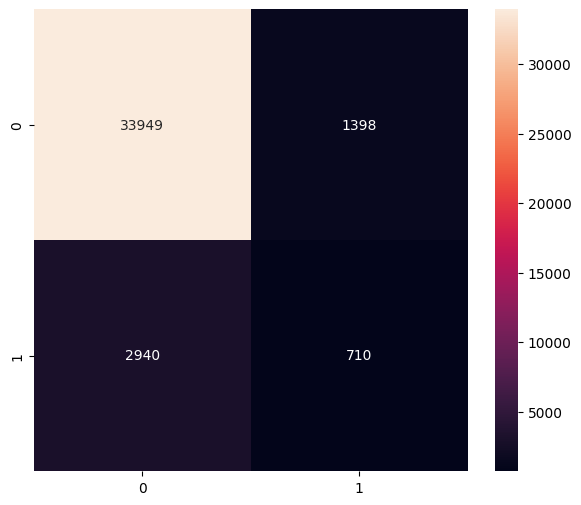

In [47]:
plt.figure(figsize=(7,6))
sb.heatmap(rf_cm, annot=True, fmt='d')

5. ANN

A feedforward artificial neural network (multi-layer perceptron) was implemented for binary heart disease classification. This architecture was selected because the dataset is tabular and does not contain spatial or sequential structure. The network consisted of two hidden dense layers with ReLU activation and a sigmoid output neuron for binary prediction.

In [54]:
ann_model = Sequential()
# first hidden layer
# has 104 neurons
# each input sample has 13 features

# each of the 104 neurons receives all 13 inputs, has 8 weights + 1 bias, and applies relu activation function
ann_model.add(Dense(104, activation='relu', input_dim=13))
ann_model.add(Dropout(0.3))
# another fully connected layer with 104 neurons, relu activation, and it automatically takes input from the previous layer
ann_model.add(Dense(104, activation='relu'))
ann_model.add(Dropout(0.3))
# another layer
ann_model.add(Dense(52, activation='relu'))
# output layer
# sigmoid outputs probability between 0 and 1
ann_model.add(Dense(1, activation='sigmoid'))
# binary_crossentropy corrects loss for binary classification
# metrics['accuracy'] tracks performance
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])
ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 104)            │         1,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 104)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 104)            │        10,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 104)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 52)             │         5,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            53 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,889 (69.88 KB)

 Trainable params: 17,889 (69.88 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = ann_model.fit(X_train_sm, Y_train_sm, epochs=100, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_4" is incompatible with the layer: expected axis -1 of input shape to have value 13, but received input with shape (None, 15)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 15), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>